In [3]:
import pandas as pd

df = pd.read_csv("../data/palmerpenguins_extended.csv")

print("BROJ REDOVA I KOLONA:")
print(df.shape)

print("\nIMENA KOLONA:")
print(df.columns)

print("\nTIPOVI PODATAKA:")
print(df.dtypes)

print("\nPRVIH 5 REDOVA:")
print(df.head())


BROJ REDOVA I KOLONA:
(3430, 11)

IMENA KOLONA:
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'diet', 'life_stage',
       'health_metrics', 'year'],
      dtype='object')

TIPOVI PODATAKA:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
diet                  object
life_stage            object
health_metrics        object
year                   int64
dtype: object

PRVIH 5 REDOVA:
  species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Biscoe            53.4           17.8              219.0   
1  Adelie  Biscoe            49.3           18.1              245.0   
2  Adelie  Biscoe            55.7           16.6              226.0   
3  Adelie  Biscoe            38.0           15.6              221.0   
4  Adelie  Biscoe            60.7     

U prvom koraku projekta izvršena je inicijalna analiza skupa podataka palmerpenguins_extended.csv. Korišćenjem funkcije df.shape utvrđeno je da dataset sadrži 3430 instanci i 11 kolona, što predstavlja dovoljno veliki uzorak za stabilno treniranje modela. Putem komande df.dtypes identifikovane su numeričke varijable (fizičke mere) i kategorički atributi (poput ostrva i ishrane)

In [2]:
import pandas as pd

df = pd.read_csv("../data/palmerpenguins_extended.csv")

numeric_cols = df.select_dtypes(include=["float64", "int64"])

print("NUMERIČKI FEATURE-I:")
print(numeric_cols.columns)

print("\nDESKRIPTIVNA STATISTIKA:")
print(numeric_cols.describe())

print("\nPROVERA NEDOSTAJUĆIH VREDNOSTI:")
print(numeric_cols.isnull().sum())


NUMERIČKI FEATURE-I:
Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g',
       'year'],
      dtype='object')

DESKRIPTIVNA STATISTIKA:
       bill_length_mm  bill_depth_mm  flipper_length_mm   body_mass_g  \
count     3430.000000    3430.000000        3430.000000   3430.000000   
mean        38.529825      18.447143         207.028863   4834.710496   
std         13.175171       2.774428          28.944765   1311.091310   
min         13.600000       9.100000         140.000000   2477.000000   
25%         28.900000      16.600000         185.000000   3843.500000   
50%         34.500000      18.400000         203.000000   4633.500000   
75%         46.600000      20.300000         226.000000   5622.000000   
max         88.200000      27.900000         308.000000  10549.000000   

              year  
count  3430.000000  
mean   2023.348397  
std       1.313797  
min    2021.000000  
25%    2022.000000  
50%    2024.000000  
75%    2024.000000  
max    2025

U nastavku analize fokus je stavljen na numeričke atribute kako bi se stekao uvid u njihove statističke karakteristike. Korišćenjem funkcije describe() dobijene su ključne vrednosti poput srednje vrednosti, standardne devijacije i kvartila, što je omogućilo preciznu identifikaciju raspona u kojima se kreću fizičke mere pingvina, poput prosečne mase od oko 4834 grama. Analiza numeričkih atributa pokazuje da podaci nemaju nedostajuće vrednosti, ali poseduju različite raspone i varijanse, što ukazuje na potrebu za standardizacijom pre primene određenih klasifikacionih algoritama.Ovakva deskriptivna statistika je neophodna prema metodologiji iz knjige "Statistical Methods for Machine Learning" jer pomaže u otkrivanju potencijalnih ekstremnih vrednosti (outliers) i razumevanju varijabiliteta unutar uzorka. Takođe, izvršena je provera kvaliteta podataka pomoću funkcije isnull().sum(), čime je potvrđeno da u numeričkim kolonama nema nedostajućih vrednosti. To znači da nije bilo potrebe za primenom tehnika imputacije koje se opisuju u "ML Python Cookbook", čime je proces pripreme podataka značajno olakšan i osigurana je stabilnost budućih modela.

In [6]:
import pandas as pd

df = pd.read_csv("../data/palmerpenguins_extended.csv")

categorical_cols = df.select_dtypes(include=["object"])

print("KATEGORIJSKI FEATURE-I:")
print(categorical_cols.columns)

for col in categorical_cols.columns:
    print(f"\n--- {col.upper()} ---")
    print("Broj jedinstvenih vrednosti:", categorical_cols[col].nunique())
    print(categorical_cols[col].value_counts())


KATEGORIJSKI FEATURE-I:
Index(['species', 'island', 'sex', 'diet', 'life_stage', 'health_metrics'], dtype='object')

--- SPECIES ---
Broj jedinstvenih vrednosti: 3
species
Adelie       1560
Gentoo       1247
Chinstrap     623
Name: count, dtype: int64

--- ISLAND ---
Broj jedinstvenih vrednosti: 3
island
Biscoe       1785
Dream        1133
Torgensen     512
Name: count, dtype: int64

--- SEX ---
Broj jedinstvenih vrednosti: 2
sex
female    1726
male      1704
Name: count, dtype: int64

--- DIET ---
Broj jedinstvenih vrednosti: 4
diet
krill       1419
fish         958
parental     860
squid        193
Name: count, dtype: int64

--- LIFE_STAGE ---
Broj jedinstvenih vrednosti: 3
life_stage
juvenile    1541
adult       1029
chick        860
Name: count, dtype: int64

--- HEALTH_METRICS ---
Broj jedinstvenih vrednosti: 3
health_metrics
healthy        1550
overweight     1167
underweight     713
Name: count, dtype: int64


Nakon numeričke analize, izvršen je detaljan pregled kategoričkih atributa kako bi se razumela njihova distribucija unutar skupa podataka. Korišćenjem funkcija nunique() i value_counts() utvrđeno je da ciljna varijabla species sadrži tri vrste, pri čemu je vrsta Adelie najzastupljenija (1560 instanci), dok Chinstrap čini najmanji deo uzorka. Ovakva analiza distribucije klasa je ključna sa stanovišta knjige "Statistical Methods for Machine Learning", jer ukazuje na blagu debalansiranost klasa, što može uticati na metrike performansi modela.

Takođe, primećeno je da su ostali atributi, poput pola (sex), lokacije (island) i ishrane (diet), ravnomerno raspoređeni ili logički grupisani, što potvrđuje kvalitet prikupljenih bioloških podataka. Razumevanje ovih kategorija je neophodan korak pre primene One-Hot Encoding tehnike iz "ML Python Cookbook", jer omogućava pravilnu transformaciju tekstualnih labela u numeričke vektore koje algoritmi mašinskog učenja mogu efikasno da obrađuju.

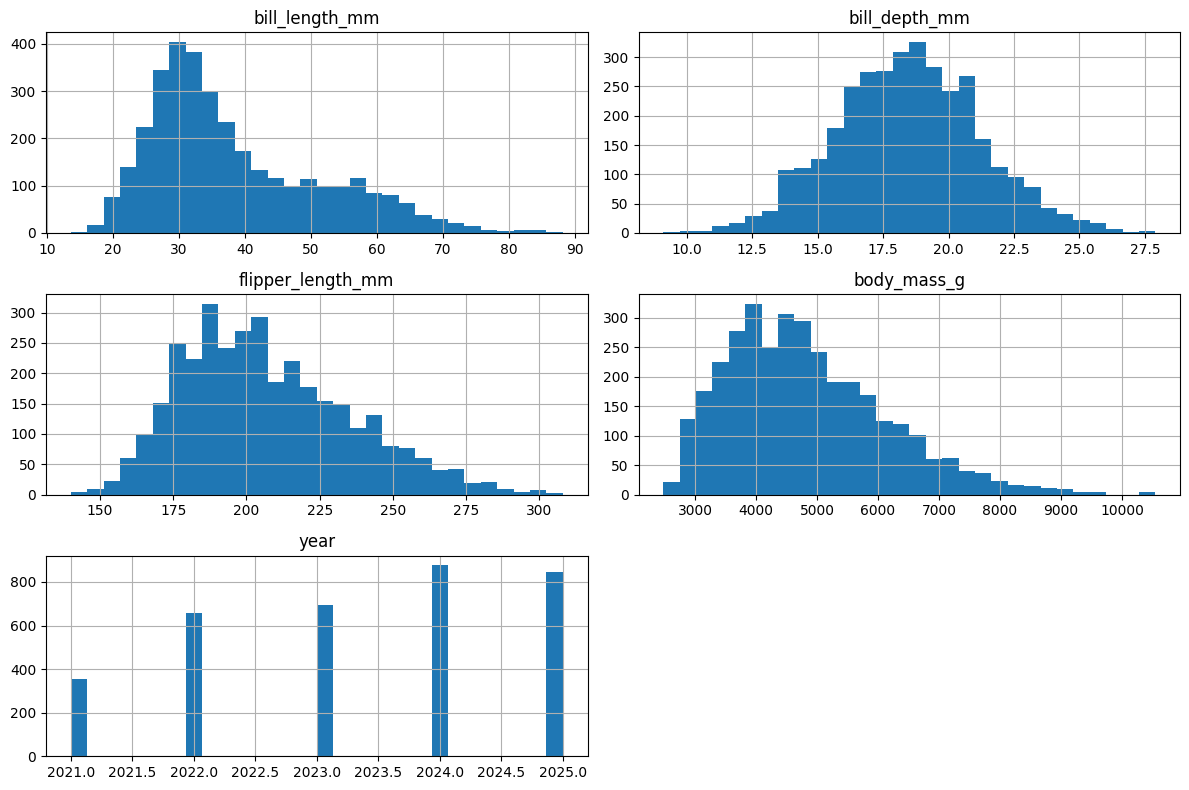

KORELACIONA MATRICA:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000       0.312916           0.669066   
bill_depth_mm            0.312916       1.000000           0.487376   
flipper_length_mm        0.669066       0.487376           1.000000   
body_mass_g              0.661170       0.558539           0.792182   
year                     0.008836      -0.014732           0.007052   

                   body_mass_g      year  
bill_length_mm        0.661170  0.008836  
bill_depth_mm         0.558539 -0.014732  
flipper_length_mm     0.792182  0.007052  
body_mass_g           1.000000 -0.001921  
year                 -0.001921  1.000000  


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/palmerpenguins_extended.csv")

numeric_cols = df.select_dtypes(include=["float64", "int64"])

numeric_cols.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

print("KORELACIONA MATRICA:")
print(numeric_cols.corr())


Nakon analize pojedinačnih kolona, izvršena je vizuelizacija distribucija i analiza međusobnih odnosa varijabli. Pomoću histograma je provereno kako su fizičke mere raspoređene, što je standardni postupak u knjizi "Statistical Methods for Machine Learning" za identifikaciju normalne raspodele ili potencijalnih asimetrija u podacima.

Poseban akcenat stavljen je na korelacionu matricu, koja je otkrila jake linearne veze između određenih karakteristika. Primećeno je da dužina peraja (flipper_length_mm) i telesna masa (body_mass_g) imaju visoku korelaciju (0.79), što je biološki logično. S druge strane, kolona year pokazuje skoro nultu korelaciju sa svim ostalim faktorima, čime je statistički potvrđeno da godina merenja ne utiče na fizičke karakteristike pingvina. Ovi nalazi su ključni za fazu odabira karakteristika (feature selection) opisanu u "ML Python Cookbook", jer omogućavaju modelu da se fokusira na najbitnije informacije i izbegne redundantne podatke.